# Image Processing: Face Recognition and Evolution

## Setup Code

In [ ]:
pip install opencv-python

In [13]:
#import libraries

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import zscore

In [18]:
#Parse dataset

data_path = "data/UTKFace"
files = os.listdir(data_path)

data = []

for file in files:
    try:
        age, gender, race, date = file.split('_')
        age, gender, race = int(age), int(gender), int(race)
        
        img = cv2.imread(os.path.join(data_path, file))
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (64, 64))
        
        data.append([img.flatten(), age, gender, race])
    except Exception as e:
        print(f"Skipping {file}: {e}")
        continue

df = pd.DataFrame(data, columns=["image", "age", "gender", "race"])
print("Amount of rows")
print(df.shape)

total_size = sum(os.path.getsize(os.path.join(data_path, f)) for f in os.listdir(data_path))
print(f"Dataset size: {total_size / (1024**2):.2f} MB")

sample_file = os.listdir(data_path)[0]

# Read one image
img = cv2.imread(os.path.join(data_path, sample_file))

# Get dimensions
height, width, channels = img.shape
print(f"Image dimensions: {width}x{height} pixels, {channels} color channels")

df.head()

Skipping 39_1_20170116174525125.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
Skipping 61_1_20170109150557335.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
Skipping 61_1_20170109142408075.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
Amount of rows
(23705, 4)
Dataset size: 114.43 MB
Image dimensions: 200x200 pixels, 3 color channels


,image,age,gender,race
0,"[71, 104, 90, 63, 93, 80, 64, 93, 82, 82, 106,...",9,1,2
1,"[39, 224, 240, 40, 219, 238, 34, 205, 230, 34,...",36,0,1
2,"[207, 227, 222, 210, 228, 221, 209, 226, 219, ...",86,1,0
3,"[252, 238, 239, 252, 238, 239, 252, 238, 239, ...",26,1,0
4,"[48, 60, 94, 42, 57, 90, 60, 77, 110, 77, 98, ...",1,1,2


## Dataset Sample Statistics

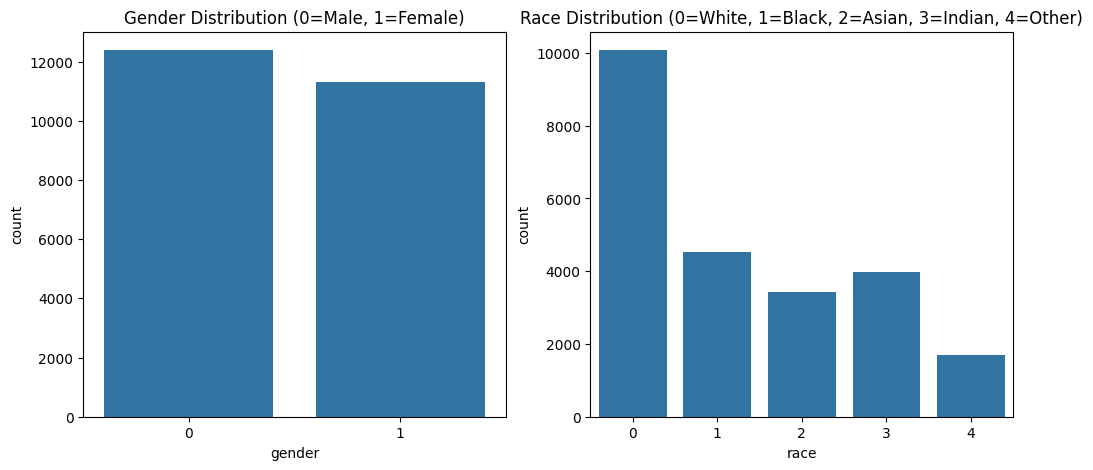

In [11]:
#Gender and Race Bar Chart
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='gender', data=df, ax=ax[0])
ax[0].set_title('Gender Distribution (0=Male, 1=Female)')
sns.countplot(x='race', data=df, ax=ax[1])
ax[1].set_title('Race Distribution (0=White, 1=Black, 2=Asian, 3=Indian, 4=Other)')
plt.show()

In [ ]:
#age frequency
df[['age']].describe()

,age
count,23705.000000
mean,33.300907
std,19.885708
min,1.000000
25%,23.000000
50%,29.000000
75%,45.000000
max,116.000000


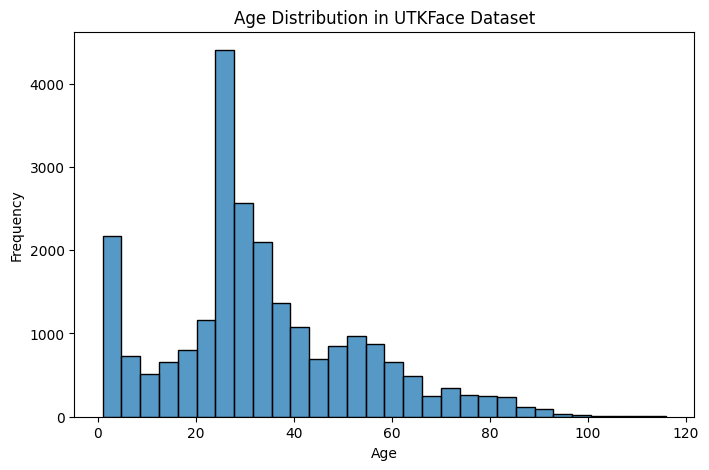

In [ ]:
#age histogram
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=False)
plt.title('Age Distribution in UTKFace Dataset')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

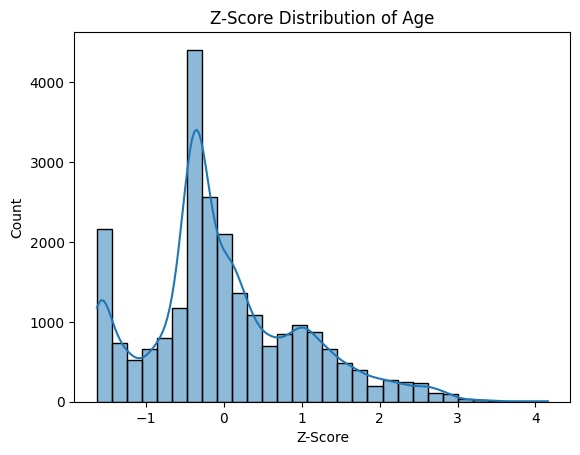

In [14]:
df['age_zscore'] = zscore(df['age'])
sns.histplot(df['age_zscore'], bins=30, kde=True)
plt.title('Z-Score Distribution of Age')
plt.xlabel('Z-Score')
plt.ylabel('Count')
plt.show()

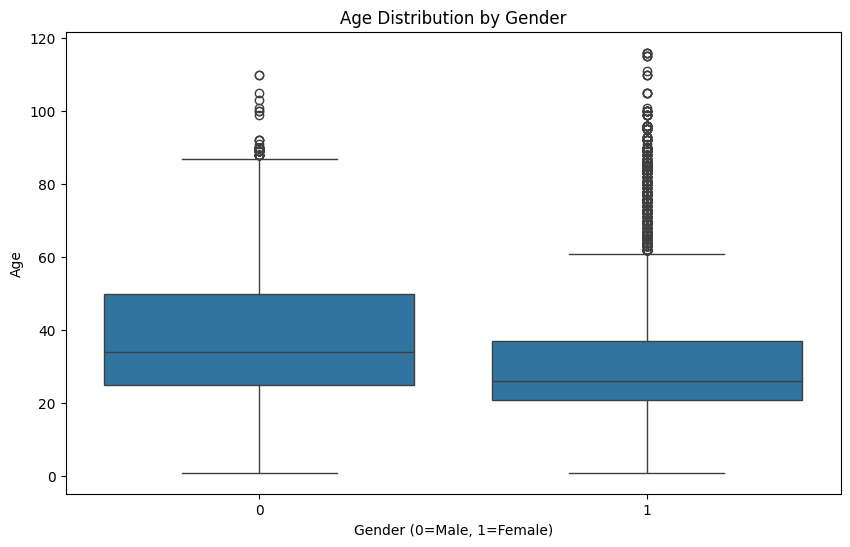

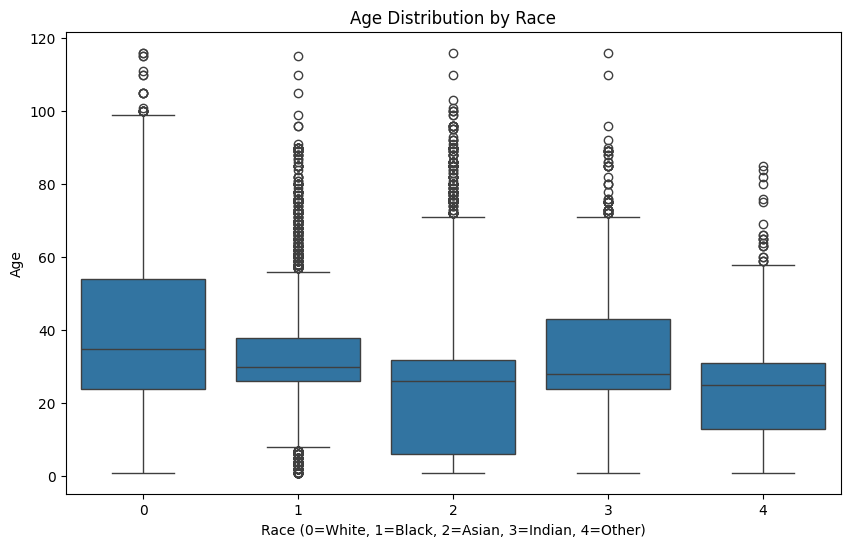

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='age', data=df)
plt.title('Age Distribution by Gender')
plt.xlabel('Gender (0=Male, 1=Female)')
plt.ylabel('Age')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='race', y='age', data=df)
plt.title('Age Distribution by Race')
plt.xlabel('Race (0=White, 1=Black, 2=Asian, 3=Indian, 4=Other)')
plt.ylabel('Age')
plt.show()

## Eigenfaces

## Face Recognition Using CNNs

## Face Evolution Using GANs